In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib


In [20]:
df = pd.read_csv("/content/dataset.csv")

print(df.shape)
df.head()


(1195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1.0,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1.0,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1.0,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1.0,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1.0,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [21]:
df["status"] = (df["status"] >= 0.5).astype(int)

In [22]:
print(df["status"].unique())
print(df["status"].dtype)

[1 0]
int64


In [23]:
X = df.drop(columns=["status", "name"])
y = df["status"]
groups = df["name"]


In [24]:
#Prepare GroupKFold
gkf = GroupKFold(n_splits=5)


In [25]:
#Containers to store results and predictions
ensemble_scores = []
dnn_scores = []

all_true_ensemble = []
all_pred_ensemble = []

all_true_dnn = []
all_pred_dnn = []


In [26]:
all_voice_probs  = []
all_voice_labels = []

#GroupKFold training loop
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print("Fold", fold + 1)

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # PCA
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Ensemble model
    lr = LogisticRegression(max_iter=1000)
    svm = SVC(kernel="rbf", probability=True)
    rf = RandomForestClassifier(n_estimators=200, random_state=42)

    ensemble = VotingClassifier(
        estimators=[
            ("lr", lr),
            ("svm", svm),
            ("rf", rf)
        ],
        voting="soft"
    )

    ensemble.fit(X_train_pca, y_train)
    proba = ensemble.predict_proba(X_test_pca)[:, 1]
    all_voice_probs.extend(proba)
    all_voice_labels.extend(y_test.values)

    np.save("voice_test_probs.npy",  np.array(all_voice_probs))
    np.save("voice_test_labels.npy", np.array(all_voice_labels))
    print("Voice test probs saved:", len(all_voice_probs))
    y_pred_ensemble = ensemble.predict(X_test_pca)

    ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
    ensemble_scores.append(ensemble_acc)

    all_true_ensemble.extend(y_test.values)
    all_pred_ensemble.extend(y_pred_ensemble)

    print("Ensemble accuracy", ensemble_acc)

    # Small deep neural network
    model = Sequential()
    model.add(Dense(64, activation="relu", input_shape=(X_train_pca.shape[1],)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_pca,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_dnn = (model.predict(X_test_pca) > 0.5).astype(int)

    dnn_acc = accuracy_score(y_test, y_pred_dnn)
    dnn_scores.append(dnn_acc)

    all_true_dnn.extend(y_test.values)
    all_pred_dnn.extend(y_pred_dnn.flatten())

    print("DNN accuracy", dnn_acc)


Fold 1
Voice test probs saved: 239
Ensemble accuracy 0.9916317991631799


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
DNN accuracy 0.9874476987447699
Fold 2
Voice test probs saved: 478
Ensemble accuracy 0.9832635983263598


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
DNN accuracy 0.9874476987447699
Fold 3
Voice test probs saved: 717
Ensemble accuracy 0.9832635983263598


...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
DNN accuracy 0.9874476987447699
Fold 4
Voice test probs saved: 956
Ensemble accuracy 0.9832635983263598


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
DNN accuracy 0.9790794979079498
Fold 5
Voice test probs saved: 1195
Ensemble accuracy 0.99581589958159


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
DNN accuracy 0.9916317991631799


In [27]:
#Final averaged results
print("\nFinal Results Across Folds")

print("Ensemble Mean Accuracy", np.mean(ensemble_scores))
print("Ensemble Std", np.std(ensemble_scores))

print("DNN Mean Accuracy", np.mean(dnn_scores))
print("DNN Std", np.std(dnn_scores))



Final Results Across Folds
Ensemble Mean Accuracy 0.9874476987447698
Ensemble Std 0.005292514912415729
DNN Mean Accuracy 0.9866108786610879
DNN Std 0.004099564423068077


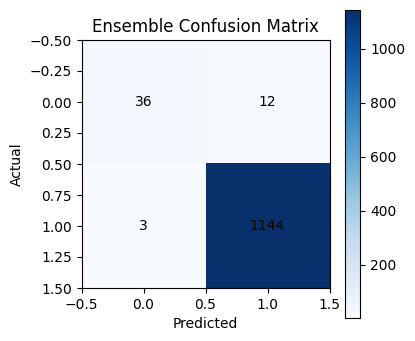

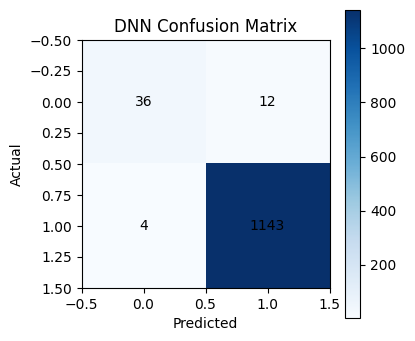

In [28]:
import matplotlib.pyplot as plt

cm_ensemble = confusion_matrix(all_true_ensemble, all_pred_ensemble)
cm_dnn = confusion_matrix(all_true_dnn, all_pred_dnn)

def plot_cm(cm, title):
    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

plot_cm(cm_ensemble, "Ensemble Confusion Matrix")
plot_cm(cm_dnn, "DNN Confusion Matrix")

In [29]:
#Train final models on full dataset for saving
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

pca_final = PCA(n_components=0.95)
X_pca = pca_final.fit_transform(X_scaled)


In [30]:
#Save ensemble model
lr = LogisticRegression(max_iter=1000)
svm = SVC(kernel="rbf", probability=True)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

ensemble_final = VotingClassifier(
    estimators=[("lr", lr), ("svm", svm), ("rf", rf)],
    voting="soft"
)

ensemble_final.fit(X_pca, y)

joblib.dump(ensemble_final, "/content/ensemble_model.pkl")
joblib.dump(scaler_final, "/content/scaler.pkl")
joblib.dump(pca_final, "/content/pca.pkl")

print("Ensemble model saved")


Ensemble model saved


In [31]:
#Save DNN model in .keras format
final_dnn = Sequential()
final_dnn.add(Dense(64, activation="relu", input_shape=(X_pca.shape[1],)))
final_dnn.add(Dropout(0.3))
final_dnn.add(Dense(32, activation="relu"))
final_dnn.add(Dense(1, activation="sigmoid"))

final_dnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_dnn.fit(X_pca, y, epochs=50, batch_size=16, verbose=0)

final_dnn.save("/content/voice_dnn_model.keras")

print("DNN model saved in .keras format")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DNN model saved in .keras format


In [32]:
ensemble_accuracy = accuracy_score(all_true_ensemble, all_pred_ensemble)
ensemble_precision = precision_score(all_true_ensemble, all_pred_ensemble)
ensemble_recall = recall_score(all_true_ensemble, all_pred_ensemble)
ensemble_f1 = f1_score(all_true_ensemble, all_pred_ensemble)

print("Ensemble Model Performance")
print("Accuracy :", ensemble_accuracy)
print("Precision :", ensemble_precision)
print("Recall :", ensemble_recall)
print("F1 Score :", ensemble_f1)


Ensemble Model Performance
Accuracy : 0.9874476987447699
Precision : 0.9896193771626297
Recall : 0.997384481255449
F1 Score : 0.9934867564046895


In [33]:

dnn_accuracy = accuracy_score(all_true_dnn, all_pred_dnn)
dnn_precision = precision_score(all_true_dnn, all_pred_dnn)
dnn_recall = recall_score(all_true_dnn, all_pred_dnn)
dnn_f1 = f1_score(all_true_dnn, all_pred_dnn)

print("\nDeep Learning Model Performance")
print("Accuracy :", dnn_accuracy)
print("Precision :", dnn_precision)
print("Recall :", dnn_recall)
print("F1 Score :", dnn_f1)




Deep Learning Model Performance
Accuracy : 0.9866108786610879
Precision : 0.9896103896103896
Recall : 0.9965126416739319
F1 Score : 0.9930495221546481
